# NLP Analysis — Consumer Complaint Narratives

This notebook explores the free-text complaint narratives: word/n-gram frequency, topic modeling (LDA), and baseline classifiers for predicting `Product` and `Issue` from the narrative text. The final cleaned-text + tuned-classifier approach here is what `nlp_model_training.py` runs on the full dataset.

**Note:** All exploration in this notebook runs on a 50,000-row sample for speed. The production training script samples up to 300,000 rows.

In [1]:
import re

import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

## 1. Load Data & Sample

In [2]:
df = pd.read_parquet(
    "../data/processed/complaints_processed.parquet",
    columns=[
        "Consumer complaint narrative",
        "Company",
        "Product",
        "Issue"
    ]
)

In [3]:
df["Consumer complaint narrative"].isna().mean() * 100

np.float64(76.16444832656921)

In [4]:
sample_df = (
    df[df["Consumer complaint narrative"].notna()]
    .sample(n=50_000, random_state=42)
    .copy()
)

sample_df.shape

(50000, 4)

In [5]:
sample_df.head(2)

,Consumer complaint narrative,Company,Product,Issue
2237546,AS A CONSUMER I AM SUBMITTING THIS REPORT TODA...,"EQUIFAX, INC.",Credit reporting or other personal consumer re...,Incorrect information on your report
5582468,Subject : Formal Dispute and Demand for Immedi...,NCB Management Services Inc.,Debt or credit management,Didn't provide services promised


## 2. Narrative Length & Category Distribution

In [6]:
sample_df["word_count"] = (
    sample_df["Consumer complaint narrative"]
    .str.split()
    .str.len()
)

sample_df["word_count"].describe()

count    50000.000000
mean       178.968480
std        232.479121
min          1.000000
25%         62.000000
50%        117.000000
75%        213.000000
max       5487.000000
Name: word_count, dtype: float64

In [7]:
sample_df["Product"].value_counts().head(20)

Product
Credit reporting or other personal consumer reports                             21885
Credit reporting, credit repair services, or other personal consumer reports    10639
Debt collection                                                                  5626
Checking or savings account                                                      2388
Mortgage                                                                         1912
Credit card                                                                      1633
Money transfer, virtual currency, or money service                               1526
Credit card or prepaid card                                                      1448
Student loan                                                                      811
Vehicle loan or lease                                                             683
Credit reporting                                                                  419
Payday loan, title loan, or personal loan     

In [8]:
sample_df["Issue"].value_counts().head(20)

Issue
Incorrect information on your report                                                15881
Improper use of your report                                                          8730
Problem with a company's investigation into an existing problem                      4534
Problem with a credit reporting company's investigation into an existing problem     3189
Attempts to collect debt not owed                                                    2344
Managing an account                                                                  1277
Written notification about debt                                                      1166
Trouble during payment process                                                        762
Problem with a purchase shown on your statement                                       745
Other transaction problem                                                             696
False statements or representation                                                    610
Took

In [9]:
product_length = (
    sample_df.groupby("Product")["word_count"]
    .mean()
    .sort_values(ascending=False)
)

product_length

Product
Mortgage                                                                        309.894351
Other financial service                                                         275.333333
Vehicle loan or lease                                                           243.090776
Consumer Loan                                                                   238.206349
Bank account or service                                                         236.553763
Student loan                                                                    228.578298
Checking or savings account                                                     227.141122
Payday loan, title loan, or personal loan                                       223.459677
Credit card or prepaid card                                                     222.437155
Credit card                                                                     209.524189
Payday loan, title loan, personal loan, or advance loan                         20

In [10]:
issue_length = (
    sample_df.groupby("Issue")["word_count"]
    .mean()
    .sort_values(ascending=False)
)

issue_length.head(10)

Issue
Managing the line of credit                              469.000000
Was approved for a loan, but didn't receive money        429.000000
Closing on a mortgage                                    396.715517
Unexpected/Other fees                                    367.000000
Struggling to pay mortgage                               358.819149
Issue where my lender is my school                       326.000000
Can't stop charges to bank account                       325.250000
Was approved for a loan, but didn't receive the money    325.142857
Balance transfer                                         321.000000
Can't contact lender or servicer                         309.272727
Name: word_count, dtype: float64

## 3. Text Cleaning

Lowercase, strip CFPB's masked tokens (`XXXX`), remove digits and punctuation, collapse whitespace. This mirrors `clean_text()` in `nlp_predictor.py` / `nlp_model_training.py`, so word/n-gram frequencies below reflect what the production model actually sees.

In [11]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"\bxx+\b", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


sample_df["clean_text"] = sample_df["Consumer complaint narrative"].apply(clean_text)
sample_df.head(3)

,Consumer complaint narrative,Company,Product,Issue,word_count,clean_text
2237546,AS A CONSUMER I AM SUBMITTING THIS REPORT TODA...,"EQUIFAX, INC.",Credit reporting or other personal consumer re...,Incorrect information on your report,235,as a consumer i am submitting this report toda...
5582468,Subject : Formal Dispute and Demand for Immedi...,NCB Management Services Inc.,Debt or credit management,Didn't provide services promised,352,subject formal dispute and demand for immediat...
1634467,There are accounts on my consumer report that ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.","Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,141,there are accounts on my consumer report that ...


## 4. Word & N-Gram Frequency (Cleaned Text)

In [12]:
cv = CountVectorizer(
    stop_words="english",
    max_features=5000
)

X = cv.fit_transform(sample_df["clean_text"])

top_words = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "count": X.sum(axis=0).A1
}).sort_values("count", ascending=False)

top_words.head(20)

,word,count
1064,credit,102326
35,account,72372
3781,report,60747
2315,information,59045
3785,reporting,49187
949,consumer,45781
39,accounts,31231
3192,payment,24027
1132,debt,21996
2252,inaccurate,18509


In [15]:
fig = px.bar(
    top_words.head(20),
    x="count",
    y="word",
    orientation="h",
    title="Top 20 Words in Complaint Narratives"
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show("browser")

In [16]:
bigram_cv = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=5000
)

X_bigram = bigram_cv.fit_transform(sample_df["clean_text"])

top_bigrams = pd.DataFrame({
    "bigram": bigram_cv.get_feature_names_out(),
    "count": X_bigram.sum(axis=0).A1
}).sort_values("count", ascending=False)

top_bigrams.head(20)

,bigram,count
1250,credit report,33183
1251,credit reporting,18051
2289,identity theft,11976
1880,fair credit,11659
3987,reporting act,10942
1088,consumer reporting,10597
3989,reporting agency,10455
115,account number,7475
4261,section states,6831
1208,credit bureaus,6534


In [17]:
trigram_cv = CountVectorizer(
    stop_words="english",
    ngram_range=(3, 3),
    max_features=5000
)

X_trigram = trigram_cv.fit_transform(sample_df["clean_text"])

top_trigrams = pd.DataFrame({
    "trigram": trigram_cv.get_feature_names_out(),
    "count": X_trigram.sum(axis=0).A1
}).sort_values("count", ascending=False)

top_trigrams.head(20)

,trigram,count
1946,fair credit reporting,10979
1342,credit reporting act,10878
1005,consumer reporting agency,8874
4464,states consumer reporting,4130
4312,section states consumer,3935
4011,reporting act fcra,3820
2563,information credit report,3276
4044,reporting agency furnish,3082
14,accordance fair credit,2808
376,agency furnish account,2703


### Word Cloud

Quick visual sanity check on the most frequent terms — same idea as the bar chart above, just a different view.

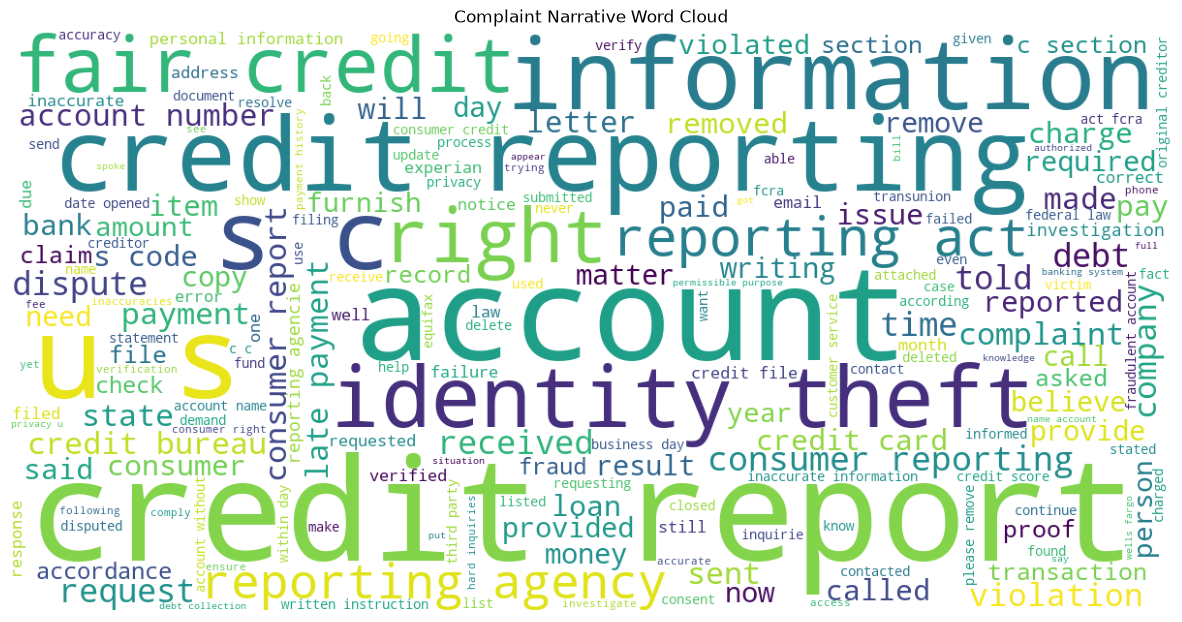

In [18]:
from wordcloud import WordCloud

text = " ".join(sample_df["clean_text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Complaint Narrative Word Cloud")
plt.show()

## 5. Topic Modeling (LDA)

Fit LDA on the cleaned narratives to discover latent topics, then manually label each topic based on its top keywords. This `topic_names` mapping is what gets used in `nlp_predictor.py` / the dashboard's NLP tab.

In [19]:
topic_cv = CountVectorizer(
    stop_words="english",
    max_features=5000,
    min_df=5
)

X_topic = topic_cv.fit_transform(sample_df["clean_text"])

lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42
)

lda.fit(X_topic)

,"random_state random_state: int, RandomState instance or None, default=NonePass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0


In [20]:
feature_names = topic_cv.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words = [
        feature_names[i]
        for i in topic.argsort()[-10:][::-1]
    ]
    print(f"\nTopic {topic_idx}")
    print(top_words)


Topic 0
['identity', 'theft', 'report', 'credit', 'accounts', 'fraudulent', 'information', 'block', 'items', 'fraud']

Topic 1
['credit', 'complaint', 'debt', 'proof', 'letters', 'unfair', 'resolution', 'filing', 'act', 'cash']

Topic 2
['debt', 'collection', 'account', 'provide', 'validation', 'original', 'reporting', 'practices', 'alleged', 'creditor']

Topic 3
['loan', 'mortgage', 'told', 'payment', 'time', 'payments', 'home', 'pay', 'received', 'loans']

Topic 4
['account', 'credit', 'date', 'balance', 'report', 'accounts', 'number', 'opened', 'information', 'reporting']

Topic 5
['account', 'bank', 'card', 'told', 'money', 'called', 'did', 'received', 'said', 'phone']

Topic 6
['credit', 'reporting', 'report', 'information', 'fcra', 'inaccurate', 'fair', 'act', 'accounts', 'violation']

Topic 7
['payment', 'late', 'payments', 'account', 'credit', 'paid', 'time', 'balance', 'error', 'history']

Topic 8
['credit', 'report', 'information', 'inquiry', 'company', 'sent', 'letter', 'di

In [21]:
topic_names = {
    0: "Identity Theft & Fraud",
    1: "Credit Complaints",
    2: "Debt Collection",
    3: "Mortgage & Loans",
    4: "Account Information",
    5: "Banking & Card Issues",
    6: "FCRA Violations",
    7: "Payment Issues",
    8: "Credit Report Disputes",
    9: "Consumer Reporting"
}

In [22]:
def predict_topic(text: str) -> str:
    cleaned = clean_text(text)
    vector = topic_cv.transform([cleaned])
    topic_probs = lda.transform(vector)
    topic_id = topic_probs.argmax()
    return topic_names[topic_id]


sample_text = """
Someone opened fraudulent accounts in my name
and there are inquiries on my credit report.
"""

predict_topic(sample_text)

'Identity Theft & Fraud'

## 6. Product Classifier

Baseline: TF-IDF + Logistic Regression to predict `Product` from the cleaned narrative. Rare product classes (fewer than 100 samples in this 50K sample) are dropped first since they don't have enough examples to train or evaluate on reliably.

In [23]:
df_model = sample_df[["clean_text", "Product"]].copy()

product_counts = df_model["Product"].value_counts()
valid_products = product_counts[product_counts >= 100].index

df_model = df_model[df_model["Product"].isin(valid_products)].copy()

df_model.shape

(49885, 2)

In [25]:
X = df_model["clean_text"]
y = df_model["Product"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(39908,)
(9977,)


In [26]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape

(39908, 10000)

In [27]:
model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

c:\Desktop\customer-complaint-intelligence\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.731983562193044
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.00      0.00      0.00        37
                                                 Checking or savings account       0.70      0.81      0.75       478
                                                               Consumer Loan       0.00      0.00      0.00        25
                                                                 Credit card       0.47      0.37      0.41       326
                                                 Credit card or prepaid card       0.48      0.42      0.44       290
                                                            Credit reporting       1.00      0.01      0.02        84
                         Credit reporting or other personal consumer reports       0.80      0.86      0.83      4377
Credit reporting, credit re

### Tuned Version

Adding bigrams, `class_weight="balanced"` (to help rarer product classes), and a slightly higher `C` for less regularization. This tuned configuration is what `nlp_model_training.py` uses for the full-scale training run.

In [28]:
tfidf_tuned = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf_tuned = tfidf_tuned.fit_transform(X_train)
X_test_tfidf_tuned = tfidf_tuned.transform(X_test)

model_tuned = LogisticRegression(
    max_iter=2000,
    n_jobs=-1,
    class_weight="balanced",
    C=2
)

model_tuned.fit(X_train_tfidf_tuned, y_train)

y_pred_tuned = model_tuned.predict(X_test_tfidf_tuned)

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned, zero_division=0))

c:\Desktop\customer-complaint-intelligence\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.71053422872607
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.06      0.08      0.07        37
                                                 Checking or savings account       0.73      0.72      0.72       478
                                                               Consumer Loan       0.00      0.00      0.00        25
                                                                 Credit card       0.37      0.48      0.42       326
                                                 Credit card or prepaid card       0.40      0.49      0.44       290
                                                            Credit reporting       0.11      0.31      0.16        84
                         Credit reporting or other personal consumer reports       0.91      0.73      0.81      4377
Credit reporting, credit rep

In [29]:
sample_text = """
Someone opened fraudulent accounts in my name and there are inquiries on my credit report.
"""

sample_text_tfidf = tfidf_tuned.transform([sample_text])
model_tuned.predict(sample_text_tfidf)[0]

'Credit reporting or other personal consumer reports'

## 7. Issue Classifier

Same TF-IDF + Logistic Regression approach, this time predicting `Issue`. Rare issue classes (fewer than 50 samples) are dropped for the same reason as above.

In [30]:
df_issue = sample_df[["clean_text", "Issue"]].dropna().copy()

issue_counts = df_issue["Issue"].value_counts()
valid_issues = issue_counts[issue_counts >= 50].index

df_issue = df_issue[df_issue["Issue"].isin(valid_issues)].copy()

print(df_issue.shape)
print(df_issue["Issue"].nunique())

(48721, 2)
57


In [31]:
X_issue = df_issue["clean_text"]
y_issue = df_issue["Issue"]

X_train_issue, X_test_issue, y_train_issue, y_test_issue = train_test_split(
    X_issue,
    y_issue,
    test_size=0.2,
    random_state=42,
    stratify=y_issue
)

In [33]:
tfidf_issue = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X_train_issue_tfidf = tfidf_issue.fit_transform(X_train_issue)
X_test_issue_tfidf = tfidf_issue.transform(X_test_issue)

In [34]:
issue_model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

issue_model.fit(X_train_issue_tfidf, y_train_issue)

y_pred_issue = issue_model.predict(X_test_issue_tfidf)

print("Accuracy:", accuracy_score(y_test_issue, y_pred_issue))
print(classification_report(y_test_issue, y_pred_issue, zero_division=0))

c:\Desktop\customer-complaint-intelligence\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.5865572088250385
                                                                                  precision    recall  f1-score   support

                                         Account opening, closing, or management       0.00      0.00      0.00        18
                         Advertising and marketing, including promotional offers       0.60      0.20      0.30        30
                     Applying for a mortgage or refinancing an existing mortgage       0.65      0.38      0.48        40
                                               Attempts to collect debt not owed       0.39      0.47      0.42       469
                                                             Can't repay my loan       0.00      0.00      0.00        10
                                      Charged fees or interest you didn't expect       0.25      0.09      0.13        23
                                                              Closing an account       0.65      0.39      0.49     

## 8. Summary

- TF-IDF + Logistic Regression gives a reasonable baseline for both Product and Issue prediction on cleaned narrative text.
- The tuned configuration (bigrams, `class_weight="balanced"`, `C=2`) is carried forward into `nlp_model_training.py` for the full-scale training run on up to 300K narratives.
- LDA topic modeling produces 10 latent topics, manually labeled here — the same `topic_names` mapping is used in the dashboard's NLP prediction tab.
- Known limitation: Product/Issue predictions currently return only the top label with no confidence score or top-3 alternatives, unlike the topic model which does expose a confidence score.